Shape of dataset: (101766, 48)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 48 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   race                      101766 non-null  object
 1   gender                    101766 non-null  object
 2   age                       101766 non-null  object
 3   weight                    101766 non-null  object
 4   admission_type_id         101766 non-null  int64 
 5   discharge_disposition_id  101766 non-null  int64 
 6   admission_source_id       101766 non-null  int64 
 7   time_in_hospital          101766 non-null  int64 
 8   payer_code                101766 non-null  object
 9   medical_specialty         101766 non-null  object
 10  num_lab_procedures        101766 non-null  int64 
 11  num_procedures            101766 non-null  int64 
 12  num_medications           101766 non-null  int64 
 13  number_outpatient         10

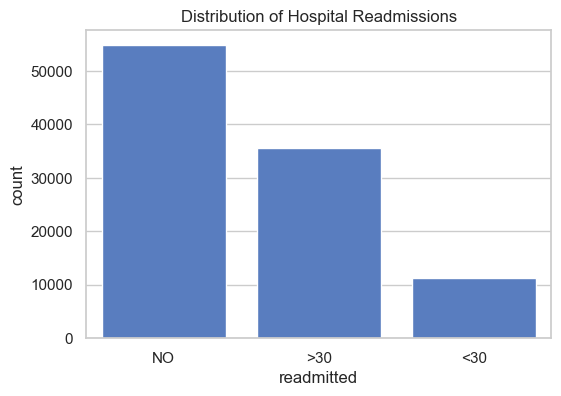

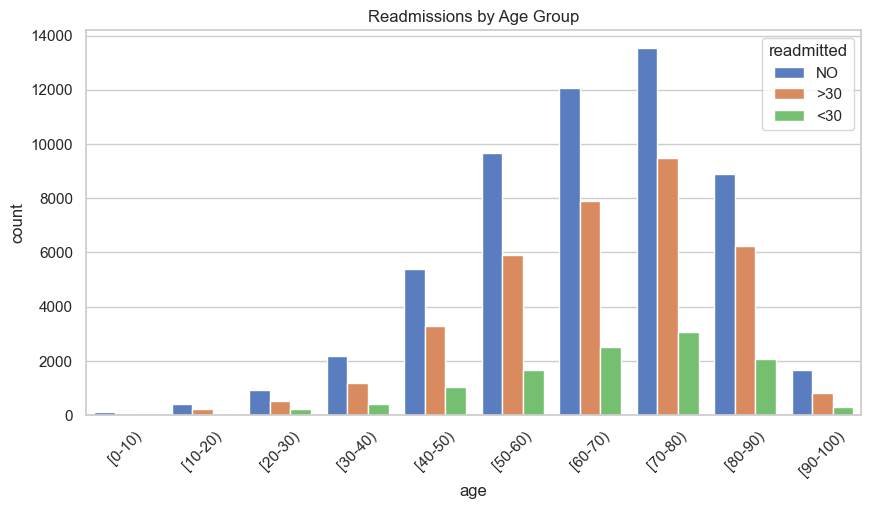

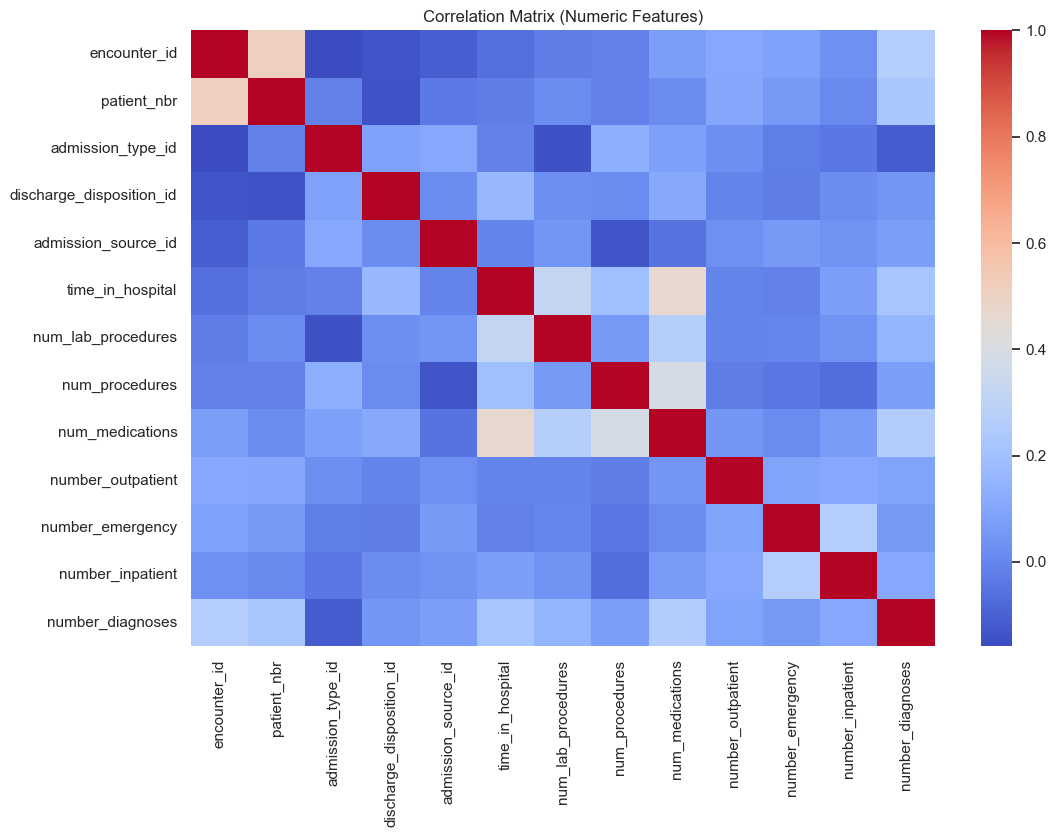


Column: gender
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64


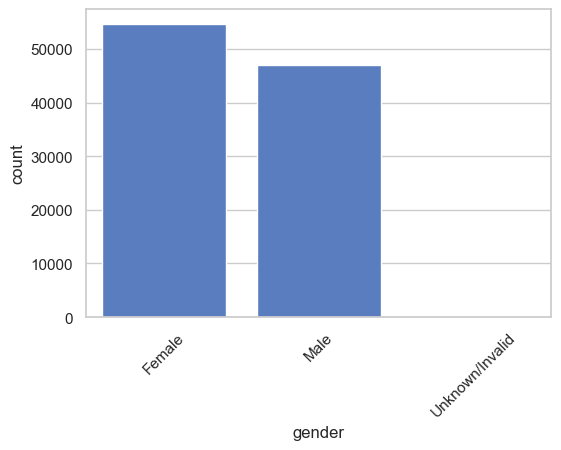


Column: race
race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64


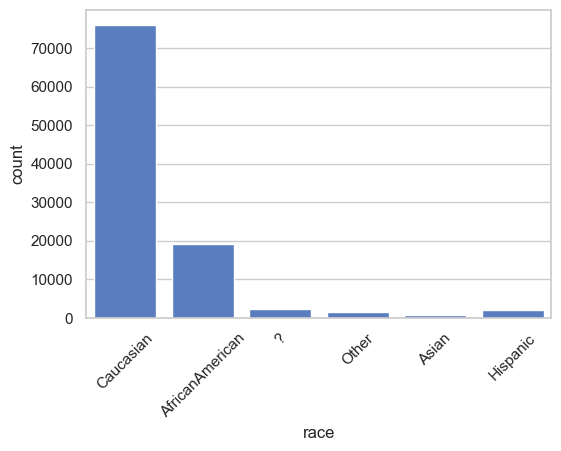


Column: admission_type_id
admission_type_id
1    53990
3    18869
2    18480
6     5291
5     4785
8      320
7       21
4       10
Name: count, dtype: int64


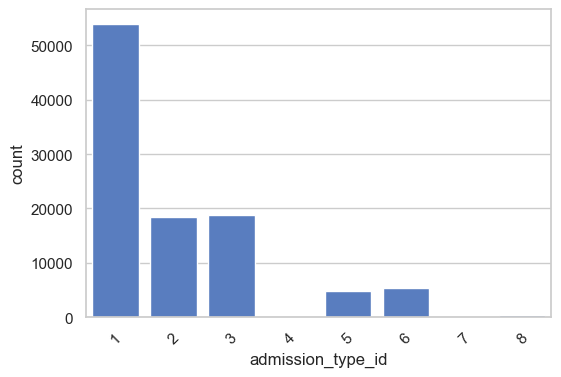


Column: discharge_disposition_id
discharge_disposition_id
1     60234
3     13954
6     12902
18     3691
2      2128
22     1993
11     1642
5      1184
25      989
4       815
7       623
23      412
13      399
14      372
28      139
8       108
15       63
24       48
9        21
17       14
16       11
19        8
10        6
27        5
12        3
20        2
Name: count, dtype: int64


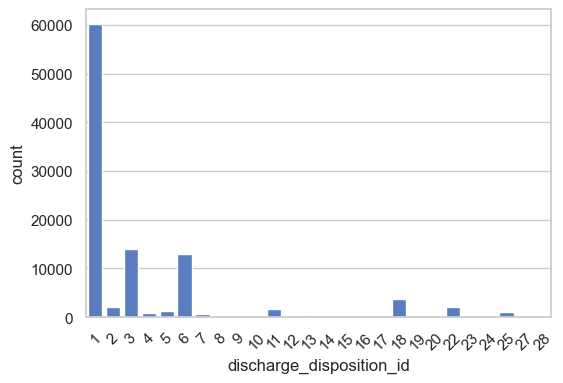

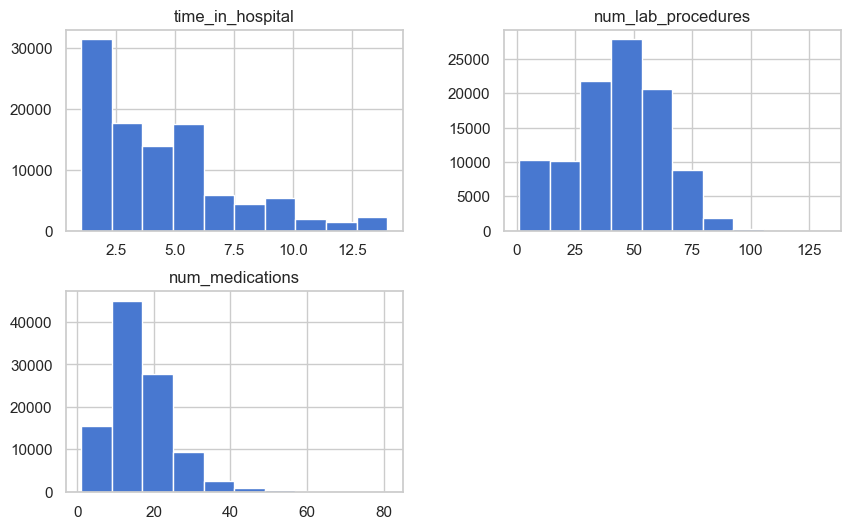

Top missing columns after replacing '?':
weight               98569
medical_specialty    49949
payer_code           40256
race                  2273
diag_3                1423
diag_2                 358
diag_1                  21
encounter_id             0
tolazamide               0
glyburide                0
dtype: int64
readmitted
0    90409
1    11357
Name: count, dtype: int64
Final dataset shape: (101766, 48)
Remaining missing values: 0


In [5]:


print("Shape of dataset:", df.shape)
df.head()

#Data inspection
df.info()
df.describe()

#check missing values
df.isnull().sum().sort_values(ascending=False)
#checking missing values in percentage
(df.isnull().mean()*100).sort_values(ascending=False)

#fix missing data by adding special category
# Define a function to fill missing values
def fill_missing(df):
    df = df.fillna({
        'max_glu_serum': 'Not Tested',
        'A1Cresult': 'Not Tested'
    })
    return df  # make sure this line is indented as well

# Apply the function
df = fill_missing(df)

df[['max_glu_serum', 'A1Cresult']].isnull().sum()


#cleaner code
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#optional: make plots look nicer
sns.set(style='whitegrid', palette='muted')
%matplotlib inline

#load dataset
data_path = "../data/raw/readmission.csv"
df = pd.read_csv(data_path)

#fill missing values safely
df = df.fillna({
    'max_glu_serum': 'Not Tested',
    'A1Cresult': 'Not Tested'
})

#confirm no missing values remain
print("Missing values after filling:")
print(df[['max_glu_serum', 'A1Cresult']].isnull().sum())

#quick overview of readmission target
readmission_counts = df['readmitted'].value_counts(normalize=True) * 100
print("\nReadmission distribution (%):")
print(readmission_counts)

#simple plot
plt.figure(figsize=(6,4))
sns.countplot(x='readmitted', data=df)
plt.title("Distribution of Hospital Readmissions")
plt.show()

#quick check: Age vs Readmission
plt.figure(figsize=(10,5))
sns.countplot(x='age', hue='readmitted', data=df)
plt.title("Readmissions by Age Group")
plt.xticks(rotation=45)
plt.show()

#correlation heatmap (numeric columns only)
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

for col in ['gender', 'race', 'admission_type_id', 'discharge_disposition_id']:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

numeric_cols = ['time_in_hospital', 'num_lab_procedures', 'num_medications']
df[numeric_cols].hist(figsize=(10,6))
plt.show()

df.replace("?", np.nan, inplace=True)

print("Top missing columns after replacing '?':")
print(df.isnull().sum().sort_values(ascending=False).head(10))

df.drop(columns=['encounter_id','patient_nbr'], inplace=True, errors='ignore')

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")

numeric_cols = df.select_dtypes(include=['int64','float64']).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['readmitted'] = df['readmitted'].map({
    '<30': 1,
    '>30': 0,
    'NO': 0
}).astype(int)

print(df['readmitted'].value_counts())

print("Final dataset shape:", df.shape)
print("Remaining missing values:", df.isnull().sum().sum())